In [2]:
import os

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

load_dotenv()

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
DB_HOST = os.getenv("DB_HOST", "127.0.0.1")
DB_PORT = int(os.getenv("DB_PORT", "3306"))
DB_USER = os.getenv("DB_USER", "root")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")
DB_NAME = "fintech_fraud_lab_class"

In [4]:
db_url = URL.create(
    "mysql+pymysql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
    query={"charset": "utf8mb4"}
)

engine = create_engine(db_url, pool_pre_ping=True)

In [5]:
query = """
SELECT TABLE_NAME 
FROM information_schema.TABLES 
WHERE TABLE_SCHEMA = %s
"""

table_list = pd.read_sql(query, engine, params=(DB_NAME,))
engine.dispose()

In [6]:
print(list(table_list['TABLE_NAME']))

['access_logs', 'accounts', 'api_request_logs', 'bureau_reports', 'campaign_experiments', 'card_payments', 'cards', 'consent_records', 'customer_inquiries', 'customers', 'data_assets', 'data_lineage_edges', 'devices', 'external_raw_records', 'financial_policy_docs', 'fraud_alerts', 'fraud_cases', 'fx_rates', 'interest_rate_curve', 'kind_collection_runs', 'kind_disclosure_chunks', 'kind_disclosures', 'kind_theme_companies', 'loan_applications', 'loans', 'login_events', 'macro_indicators', 'market_prices', 'merchants', 'mlops_pipeline_runs', 'model_drift_metrics', 'model_predictions', 'model_registry', 'news_documents', 'product_documents', 'public_card_spend_agg', 'public_merchants', 'repayment_schedules', 'transactions']


In [5]:
table_name = 'loan_applications'

q = """
SELECT *
FROM loan_applications
"""

In [6]:
df = pd.read_sql(q, engine)

In [9]:
# 데이터 크기: (180,000, 15)
# 중복 여부 확인
# 고객별 대출 신청 건 수 확인

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   application_id      180000 non-null  int64         
 1   customer_id         180000 non-null  int64         
 2   application_at      180000 non-null  datetime64[us]
 3   product_type        180000 non-null  str           
 4   requested_amount    180000 non-null  float64       
 5   approved_amount     180000 non-null  float64       
 6   loan_purpose        180000 non-null  str           
 7   annual_income       180000 non-null  float64       
 8   employment_years    180000 non-null  float64       
 9   debt_to_income      180000 non-null  float64       
 10  bureau_score        180000 non-null  int64         
 11  internal_css_score  180000 non-null  float64       
 12  approved            180000 non-null  int64         
 13  interest_rate       137094 non-null  flo

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
application_id,"180,000.00","90,000.50",1.00,"45,000.75","90,000.50","135,000.25","180,000.00","51,961.67"
customer_id,"180,000.00","60,120.67",1.00,"30,273.50","60,157.00","90,089.00","119,999.00","34,607.60"
application_at,180000,2023-08-01 07:06:10.688622,2021-08-01 00:02:53,2022-08-01 09:53:10.250000,2023-07-31 15:46:33.500000,2024-07-30 22:41:12.500000,2025-07-31 23:56:32,NaN
requested_amount,"180,000.00","44,530,502.02","401,167.59","8,030,585.13","15,537,786.56","32,839,827.12","2,682,130,298.32","91,390,854.34"
approved_amount,"180,000.00","15,557,453.94",0.00,"1,443,078.50","6,922,305.71","15,196,086.21","1,376,659,911.22","37,214,164.33"
annual_income,"180,000.00","61,038,078.48","5,960,345.27","32,869,348.20","49,298,461.42","75,001,489.61","627,413,602.09","42,416,760.09"
employment_years,"180,000.00",5.65,0.00,2.80,5.50,8.17,22.96,3.70
debt_to_income,"180,000.00",0.37,0.00,0.08,0.17,0.44,1.50,0.45
bureau_score,"180,000.00",711.80,308.00,646.00,712.00,779.00,950.00,96.17
internal_css_score,"180,000.00",834.17,162.43,814.13,865.38,894.69,999.00,107.00


## 품질 점검

In [12]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_rate_pct": df.isna().mean().mul(100),
    "nunique": df.nunique(dropna=False)
})
display(quality.sort_values("missing_rate_pct", ascending=False).head(15))

print("application_id 중복:", df.duplicated(subset=["application_id"]).sum())
# print("금액 0 이하:", (fds["amount"] <= 0).sum())
# print("날짜 결측:", fds["payment_at"].isna().sum())

,dtype,missing_count,missing_rate_pct,nunique
interest_rate,float64,42906,23.84,40109
default_12m_label,float64,42906,23.84,3
application_id,int64,0,0.00,180000
product_type,str,0,0.00,5
requested_amount,float64,0,0.00,179997
customer_id,int64,0,0.00,93316
application_at,datetime64[us],0,0.00,179883
loan_purpose,str,0,0.00,8
approved_amount,float64,0,0.00,137092
annual_income,float64,0,0.00,179998


application_id 중복: 0


In [13]:
# groupby()
# 고객 당 대출 신청 건수 확인하기
customer_eda = (
    df.groupby("customer_id", dropna=False, as_index=False)
    .agg(
        event_count=("application_id", "count"),
        amount_median=("requested_amount", "median"),
        approve_median=("approved_amount", "median"),
    )
    .sort_values("event_count", ascending=False)
)

In [14]:
display(customer_eda)

,customer_id,event_count,amount_median,approve_median
30499,39302,12,"24,358,516.65",0.00
20674,26679,10,"23,917,732.65",0.00
26033,33555,9,"18,978,652.11","6,061,555.17"
45956,59236,9,"46,772,696.18","6,520,854.74"
64777,83448,8,"24,412,550.92",0.00
...,...,...,...,...
3,4,1,"112,230,579.42","72,488,228.19"
93314,119998,1,"119,691,764.05",0.00
93311,119995,1,"6,594,615.80",0.00
93310,119994,1,"10,565,993.73","6,299,060.76"


In [53]:
# 기간 확인
# 월별 신청 건수
min_application_at = df['application_at'].min()
max_application_at = df['application_at'].max()
print(min_application_at, max_application_at)

2021-08-01 00:02:53 2025-07-31 23:56:32


In [54]:
time_eda = (
    df.groupby(df["application_at"].dt.to_period("M"))
      .size()
      .reset_index(name="monthly_count")
)

time_eda["monthly_ratio"] = (
    time_eda["monthly_count"]/len(df)*100)
#display(time_eda)

In [51]:
import matplotlib.pyplot as plt

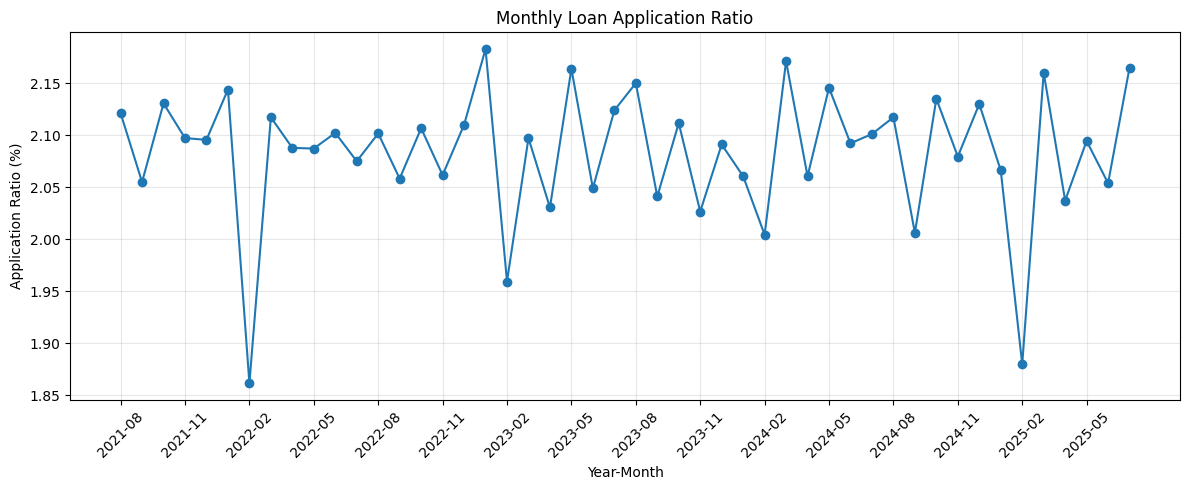

In [52]:
plt.figure(figsize=(12, 5))

plt.plot(
    time_eda["application_at"].astype(str),
    time_eda["monthly_ratio"],
    marker="o"
)

plt.xlabel("Year-Month")
plt.ylabel("Application Ratio (%)")
plt.title("Monthly Loan Application Ratio")

plt.xticks(
    range(0, len(time_eda), 3),
    time_eda["application_at"].astype(str).iloc[::3],
    rotation=45
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
# default_12m_label 분포
label_eda = (
    df.groupby("default_12m_label", dropna=False, as_index=False)
    .agg(
        event_count=("application_id", "count")
    )
)
label_eda["label_ratio"] = (
    label_eda["event_count"]/len(df)*100)

In [58]:
label_eda

,default_12m_label,event_count,label_ratio
0,0.00,131539,73.08
1,1.00,5555,3.09
2,NaN,42906,23.84


In [65]:
df.loc[
    df["default_12m_label"].isna(),
    "application_at"
].describe()
(
    df.assign(
        year_month=df["application_at"].dt.to_period("M"),
        label_missing=df["default_12m_label"].isna()
    )
    .groupby("year_month")["label_missing"]
    .agg(["count", "sum", "mean"])
).T

year_month,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
count,"3,818.00","3,699.00","3,835.00","3,775.00","3,772.00","3,859.00","3,351.00","3,811.00","3,758.00","3,757.00","3,784.00","3,735.00","3,783.00","3,705.00","3,792.00","3,711.00","3,798.00","3,929.00","3,527.00","3,775.00","3,655.00","3,895.00","3,688.00","3,823.00","3,870.00","3,674.00","3,801.00","3,648.00","3,764.00","3,709.00","3,608.00","3,908.00","3,709.00","3,862.00","3,766.00","3,782.00","3,811.00","3,611.00","3,843.00","3,743.00","3,834.00","3,719.00","3,384.00","3,888.00","3,667.00","3,770.00","3,697.00","3,897.00"
sum,862.00,846.00,896.00,903.00,889.00,884.00,808.00,905.00,887.00,838.00,907.00,910.00,891.00,901.00,910.00,953.00,863.00,964.00,855.00,948.00,839.00,915.00,864.00,888.00,912.00,850.00,940.00,900.00,883.00,915.00,849.00,956.00,898.00,909.00,922.00,927.00,899.00,845.00,933.00,889.00,959.00,889.00,766.00,949.00,891.00,877.00,888.00,934.00
mean,0.23,0.23,0.23,0.24,0.24,0.23,0.24,0.24,0.24,0.22,0.24,0.24,0.24,0.24,0.24,0.26,0.23,0.25,0.24,0.25,0.23,0.23,0.23,0.23,0.24,0.23,0.25,0.25,0.23,0.25,0.24,0.24,0.24,0.24,0.24,0.25,0.24,0.23,0.24,0.24,0.25,0.24,0.23,0.24,0.24,0.23,0.24,0.24


In [66]:
pd.crosstab(
    df["approved"],
    df["default_12m_label"].isna(),
    normalize="index"
)

default_12m_label,False,True
approved,,
0,0.00,1.00
1,1.00,0.00


In [7]:
model_df = df[df["approved"]==1].copy()

In [68]:
model_df.info()

<class 'pandas.DataFrame'>
Index: 137094 entries, 2 to 179999
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   application_id      137094 non-null  int64         
 1   customer_id         137094 non-null  int64         
 2   application_at      137094 non-null  datetime64[us]
 3   product_type        137094 non-null  str           
 4   requested_amount    137094 non-null  float64       
 5   approved_amount     137094 non-null  float64       
 6   loan_purpose        137094 non-null  str           
 7   annual_income       137094 non-null  float64       
 8   employment_years    137094 non-null  float64       
 9   debt_to_income      137094 non-null  float64       
 10  bureau_score        137094 non-null  int64         
 11  internal_css_score  137094 non-null  float64       
 12  approved            137094 non-null  int64         
 13  interest_rate       137094 non-null  float64 

In [69]:
# default_12m_label 분포
label_eda = (
    model_df.groupby("default_12m_label", dropna=False, as_index=False)
    .agg(
        event_count=("application_id", "count")
    )
)
label_eda["label_ratio"] = (
    label_eda["event_count"]/len(df)*100)

In [70]:
label_eda

,default_12m_label,event_count,label_ratio
0,0.00,131539,73.08
1,1.00,5555,3.09


In [86]:
# 월별 default_rate
# t월의 연체된 신청 건수/t월의 전체 승인신청건수

monthly_default = (
    model_df.assign(
        year_month=model_df["application_at"].dt.to_period("M"),
    )
    .groupby("year_month")["default_12m_label"]
    .agg(
        application_count="count",
        default_count="sum",
        default_rate="mean",
    )
)
monthly_default["default_rate"] *= 100

In [87]:
monthly_default

,application_count,default_count,default_rate
year_month,,,
2021-08,2956,104.00,3.52
2021-09,2853,85.00,2.98
2021-10,2939,112.00,3.81
2021-11,2872,110.00,3.83
2021-12,2883,118.00,4.09
2022-01,2975,131.00,4.40
2022-02,2543,101.00,3.97
2022-03,2906,112.00,3.85
2022-04,2871,123.00,4.28


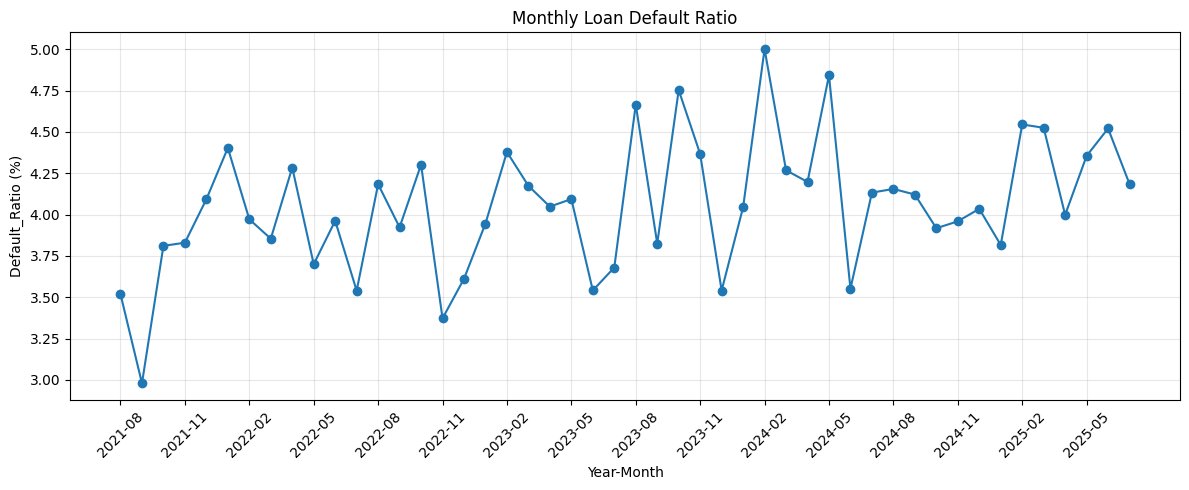

In [163]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_default.index.astype(str),
    monthly_default["default_rate"],
    marker="o"
)

plt.xlabel("Year-Month")
plt.ylabel("Default_Ratio (%)")
plt.title("Monthly Loan Default Ratio")

plt.xticks(
    range(0, len(monthly_default), 3),
    monthly_default.index.astype(str)[::3],
    rotation=45
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "Monthly Loan Default Ratio.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [90]:
monthly_default["default_rate"].agg(
    ["mean", "min", "max", "std"]
)

mean   4.05
min    2.98
max    5.00
std    0.40
Name: default_rate, dtype: float64

In [91]:
model_df.columns

Index(['application_id', 'customer_id', 'application_at', 'product_type',
       'requested_amount', 'approved_amount', 'loan_purpose', 'annual_income',
       'employment_years', 'debt_to_income', 'bureau_score',
       'internal_css_score', 'approved', 'interest_rate', 'default_12m_label'],
      dtype='str')

In [92]:
baseline_features = [
    "requested_amount",
    "annual_income",
    "employment_years",
    "debt_to_income",
    "bureau_score",
    "internal_css_score",
    "product_type",
    "loan_purpose"
]

In [96]:
model_df[baseline_features].isna().sum()

requested_amount      0
annual_income         0
employment_years      0
debt_to_income        0
bureau_score          0
internal_css_score    0
product_type          0
loan_purpose          0
dtype: int64

In [94]:
numeric_features = [
    "requested_amount",
    "annual_income",
    "employment_years",
    "debt_to_income",
    "bureau_score",
    "internal_css_score"
]
model_df[numeric_features].descri

,count,mean,std,min,25%,50%,75%,max
requested_amount,"137,094.00","27,222,860.11","53,910,889.18","401,167.59","7,421,335.61","13,659,469.10","25,268,913.68","1,722,372,302.99"
annual_income,"137,094.00","65,491,912.35","44,229,096.66","7,746,290.64","35,939,214.35","53,370,573.99","80,447,729.37","627,413,602.09"
employment_years,"137,094.00",5.75,3.71,0.00,2.92,5.61,8.28,22.96
debt_to_income,"137,094.00",0.25,0.30,0.00,0.07,0.14,0.31,1.50
bureau_score,"137,094.00",727.99,89.14,384.00,664.00,726.00,790.00,950.00
internal_css_score,"137,094.00",874.48,41.29,701.45,853.24,879.55,902.11,999.00


In [97]:
check_features = [
    "requested_amount",
    "annual_income",
    "debt_to_income"
]

In [99]:
model_df[check_features].quantile(
    [0.90, 0.95, 0.99, 0.995, 1.0]
)

,requested_amount,annual_income,debt_to_income
0.90,"49,379,426.55","120,626,182.79",0.59
0.95,"93,311,212.45","154,197,367.79",0.88
0.99,"271,162,650.42","228,834,328.01",1.50
0.99,"368,623,167.05","260,549,953.53",1.50
1.00,"1,722,372,302.99","627,413,602.09",1.50


In [100]:
(model_df["debt_to_income"] == 1.5).sum()

np.int64(2746)

In [101]:
(model_df["debt_to_income"] == 1.5).mean() * 100

np.float64(2.0030052372824487)

In [104]:
# requested_amount 상위 1% 기준값
threshold = model_df["requested_amount"].quantile(0.99)

# 상위 1% 데이터
top_1pct = model_df[
    model_df["requested_amount"] >= threshold
]

# product_type별 건수와 비율
product_dist = (
    top_1pct["product_type"]
    .value_counts()
    .to_frame("count")
)
product_dist["ratio"] = (
    product_dist["count"] / len(top_1pct) * 100
)

product_dist

,count,ratio
product_type,,
MORTGAGE,1300,94.82
SME_LOAN,71,5.18


In [105]:
model_df.groupby("product_type")["requested_amount"].describe()

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
AUTO_LOAN,"21,022.00","28,407,332.80","18,999,137.10","1,751,914.56","15,553,684.40","23,799,780.24","35,777,080.14","214,092,699.95"
CREDIT_LINE,"38,113.00","7,307,627.94","5,201,817.30","401,167.59","3,834,698.40","5,977,403.95","9,185,216.50","82,573,546.96"
MORTGAGE,"6,335.00","197,687,289.91","150,020,489.95","15,905,978.19","101,636,992.24","154,899,295.34","244,817,038.02","1,722,372,302.99"
PERSONAL_LOAN,"66,412.00","17,798,885.26","12,218,538.97","1,227,883.50","9,572,994.46","14,717,101.81","22,451,283.56","212,003,804.59"
SME_LOAN,"5,212.00","80,964,631.83","57,413,153.04","3,691,569.44","43,770,725.41","65,791,350.42","100,652,853.79","770,200,307.69"


In [109]:
# 상위 1% 데이터
debt_df = model_df[
    model_df["debt_to_income"] == 1.5
]
len(debt_df)

2746

In [110]:
len(debt_df)/len(model_df) * 100

2.0030052372824487

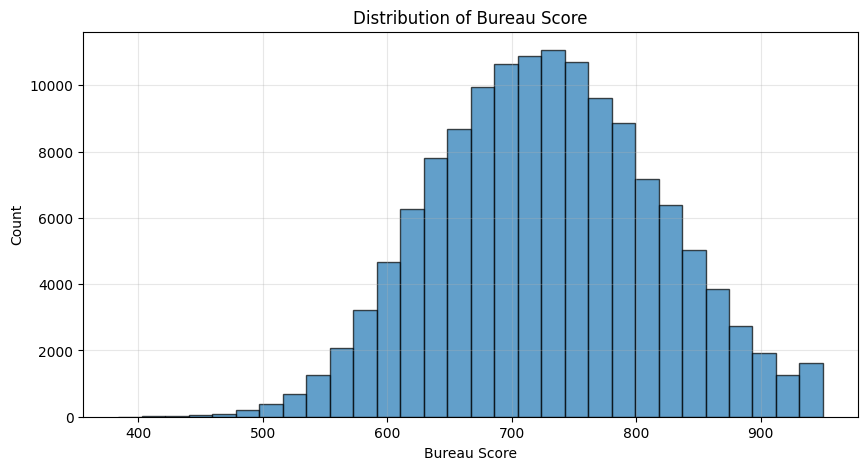

In [166]:
plt.figure(figsize=(10, 5))

plt.hist(
    model_df["bureau_score"],
    bins=30,
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("Bureau Score")
plt.ylabel("Count")
plt.title("Distribution of Bureau Score")
plt.grid(alpha=0.3)
plt.savefig(
    "distribution_of_internal_bureau_score.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

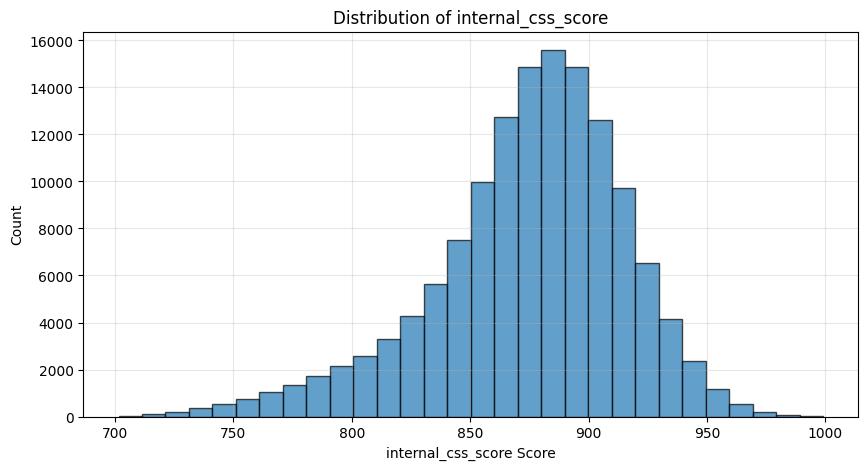

In [164]:
plt.figure(figsize=(10, 5))

plt.hist(
    model_df["internal_css_score"],
    bins=30,
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("internal_css_score Score")
plt.ylabel("Count")
plt.title("Distribution of internal_css_score")
plt.grid(alpha=0.3)

plt.savefig(
    "distribution_of_internal_css_score.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [113]:
model_df["bureau_score_bin"] = pd.cut(
    model_df["bureau_score"],
    bins=range(350, 1001, 50)
)

bureau_default = (
    model_df
    .groupby("bureau_score_bin", observed=True)["default_12m_label"]
    .agg(["count", "mean"])
)

bureau_default["default_rate"] = bureau_default["mean"] * 100

bureau_default

,count,mean,default_rate
bureau_score_bin,,,
"(350, 400]",4,0.50,50.00
"(400, 450]",59,0.08,8.47
"(450, 500]",363,0.09,9.09
"(500, 550]",2046,0.09,9.29
"(550, 600]",7614,0.07,7.42
"(600, 650]",17584,0.05,5.25
"(650, 700]",26036,0.05,4.52
"(700, 750]",28790,0.04,3.85
"(750, 800]",25080,0.03,3.15


In [114]:
model_df["annual_income_bin"] = pd.cut(
    model_df["annual_income"],
    bins=range(0, 700_000_001, 50_000_000)
)

annual_income_default = (
    model_df
    .groupby("annual_income_bin", observed=True)["default_12m_label"]
    .agg(["count", "mean"])
)

annual_income_default["default_rate"] = (
    annual_income_default["mean"] * 100
)

annual_income_defaultmodel_df["internal_css_score"] = pd.cut(
    model_df["internal_css_score"],
    bins=range(350, 1001, 50)
)

internal_css_default = (
    model_df
    .groupby("internal_css_score", observed=True)["default_12m_label"]
    .agg(["count", "mean"])
)

internal_css_default["default_rate"] = internal_css_default["mean"] * 100

internal_css_default

,count,mean,default_rate
internal_css_score,,,
"(700, 750]",1220,0.20,20.00
"(750, 800]",6882,0.15,15.10
"(800, 850]",23281,0.07,7.19
"(850, 900]",68516,0.03,2.79
"(900, 950]",35246,0.02,1.85
"(950, 1000]",1949,0.02,1.80


In [124]:
model_df["annual_income_bin"] = pd.cut(
    model_df["annual_income"],
    bins=range(0, 700_000_001, 50_000_000)
)

annual_income_default = (
    model_df
    .groupby("annual_income_bin", observed=True)["default_12m_label"]
    .agg(["count", "mean"])
)

annual_income_default["default_rate"] = (
    annual_income_default["mean"] * 100
)

annual_income_default

,count,mean,default_rate
annual_income_bin,,,
"(0, 50000000]",62540,0.05,5.01
"(50000000, 100000000]",53036,0.03,3.47
"(100000000, 150000000]",14104,0.03,2.74
"(150000000, 200000000]",4806,0.03,2.77
"(200000000, 250000000]",1738,0.02,2.42
"(250000000, 300000000]",574,0.02,2.26
"(300000000, 350000000]",191,0.02,1.57
"(350000000, 400000000]",73,0.04,4.11
"(400000000, 450000000]",21,0.05,4.76


In [125]:
import numpy as np

model_df["dti_bin"] = pd.cut(
    model_df["debt_to_income"],
    bins=np.arange(0, 1.51, 0.1),
    include_lowest=True
)

dti_default = (
    model_df
    .groupby("dti_bin", observed=True)["default_12m_label"]
    .agg(["count", "mean"])
)

dti_default["default_rate"] = dti_default["mean"] * 100

dti_default

,count,mean,default_rate
dti_bin,,,
"(-0.001, 0.1]",52126,0.03,3.14
"(0.1, 0.2]",32532,0.03,3.42
"(0.2, 0.3]",17393,0.04,3.76
"(0.3, 0.4]",10381,0.04,3.57
"(0.4, 0.5]",6798,0.04,4.25
"(0.5, 0.6]",4358,0.05,5.03
"(0.6, 0.7]",2985,0.06,5.56
"(0.7, 0.8]",2273,0.05,5.24
"(0.8, 0.9]",1633,0.06,6.43


In [135]:
model_df["employment_years_bin"] = pd.cut(
    model_df["employment_years"],
    bins=range(0, 30, 5)
)

employment_years_default = (
    model_df
    .groupby("employment_years_bin", observed=True)["default_12m_label"]
    .agg(["count", "mean"])
)

employment_years_default["default_rate"] = (
    employment_years_default["mean"] * 100
)

employment_years_default

,count,mean,default_rate
employment_years_bin,,,
"(0, 5]",49012,0.04,4.31
"(5, 10]",58577,0.04,3.93
"(10, 15]",17146,0.04,3.58
"(15, 20]",1224,0.03,3.02
"(20, 25]",21,0.00,0.00


In [136]:
product_default = (
    model_df
    .groupby("product_type")["default_12m_label"]
    .agg(["count", "mean"])
)

product_default["default_rate"] = (
    product_default["mean"] * 100
)

product_default

,count,mean,default_rate
product_type,,,
AUTO_LOAN,21022,0.04,3.89
CREDIT_LINE,38113,0.04,3.51
MORTGAGE,6335,0.10,10.37
PERSONAL_LOAN,66412,0.04,3.61
SME_LOAN,5212,0.07,6.58


In [168]:
model_df["amount_group"] = (
    model_df
    .groupby("product_type")["requested_amount"]
    .transform(
        lambda x: pd.qcut(
            x,
            q=5,
            labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
        )
    )
)

In [170]:
amount_default = (
    model_df
    .groupby(
        ["product_type", "amount_group"],
        observed=True
    )["default_12m_label"]
    .agg(["count", "mean"])
)

amount_default["default_rate"] = (
    amount_default["mean"] * 100
)

amount_default

count  mean  default_rate
product_type  amount_group                           
AUTO_LOAN     Q1             4205  0.03          3.40
              Q2             4204  0.04          3.52
              Q3             4204  0.04          3.73
              Q4             4204  0.04          3.78
              Q5             4205  0.05          4.99
CREDIT_LINE   Q1             7623  0.04          3.69
              Q2             7622  0.03          3.24
              Q3             7623  0.04          3.53
              Q4             7622  0.03          3.45
              Q5             7623  0.04          3.66
MORTGAGE      Q1             1267  0.06          6.31
              Q2             1267  0.08          7.89
              Q3             1267  0.09          8.84
              Q4             1267  0.13         12.63
              Q5             1267  0.16         16.18
PERSONAL_LOAN Q1            13283  0.04          3.63
              Q2            13282  0.04          3.54
              Q3            13282  0.04          3.70
              Q4            13282  0.03          3.26
              Q5            13283  0.04          3.94
SME_LOAN      Q1             1043  0.05          5.37
              Q2             1042  0.05          4.70
              Q3             1042  0.06          5.76
              Q4             1042  0.07          7.29
              Q5             1043  0.10          9.78

In [174]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

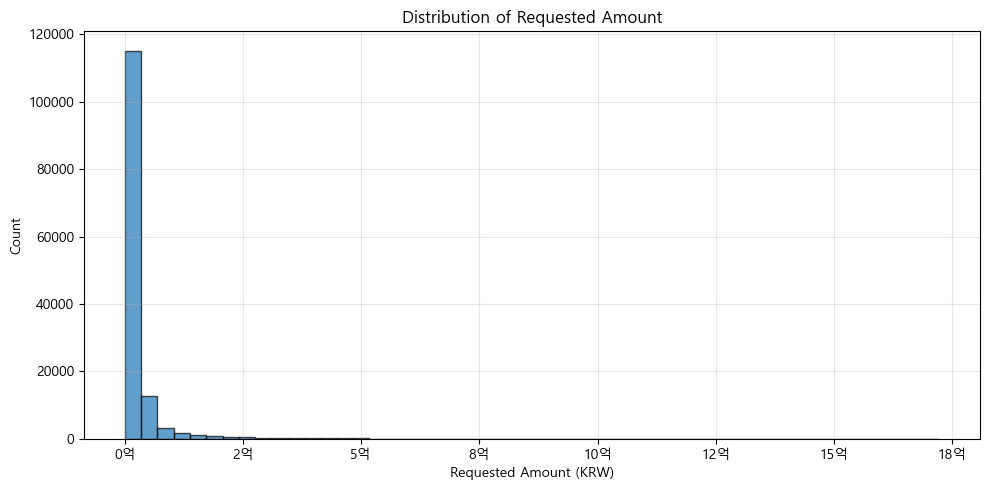

In [179]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 5))

plt.hist(
    model_df["requested_amount"],
    bins=50,
    edgecolor="black",
    alpha=0.7
)

# x축을 억 원 단위로 표시
def format_amount(x, pos):
    return f"{x / 100_000_000:.0f}억"

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_amount))

plt.xlabel("Requested Amount (KRW)")
plt.ylabel("Count")
plt.title("Distribution of Requested Amount")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "distribution_of_requested_amount.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

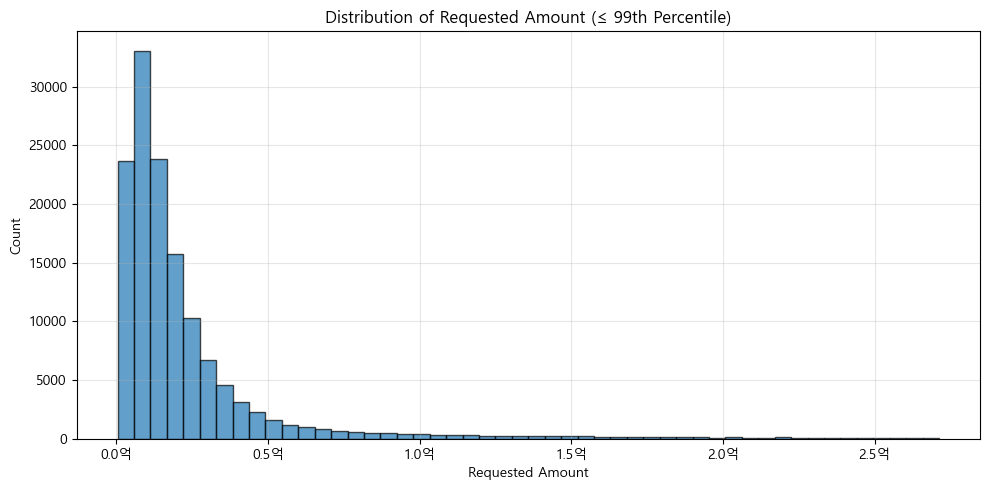

In [180]:
upper_99 = model_df["requested_amount"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    model_df.loc[
        model_df["requested_amount"] <= upper_99,
        "requested_amount"
    ],
    bins=50,
    edgecolor="black",
    alpha=0.7
)

# x축 금액을 억 단위로 표시
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 100_000_000:.1f}억")
)

plt.xlabel("Requested Amount")
plt.ylabel("Count")
plt.title("Distribution of Requested Amount (≤ 99th Percentile)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "requested_amount_distribution_99pct.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

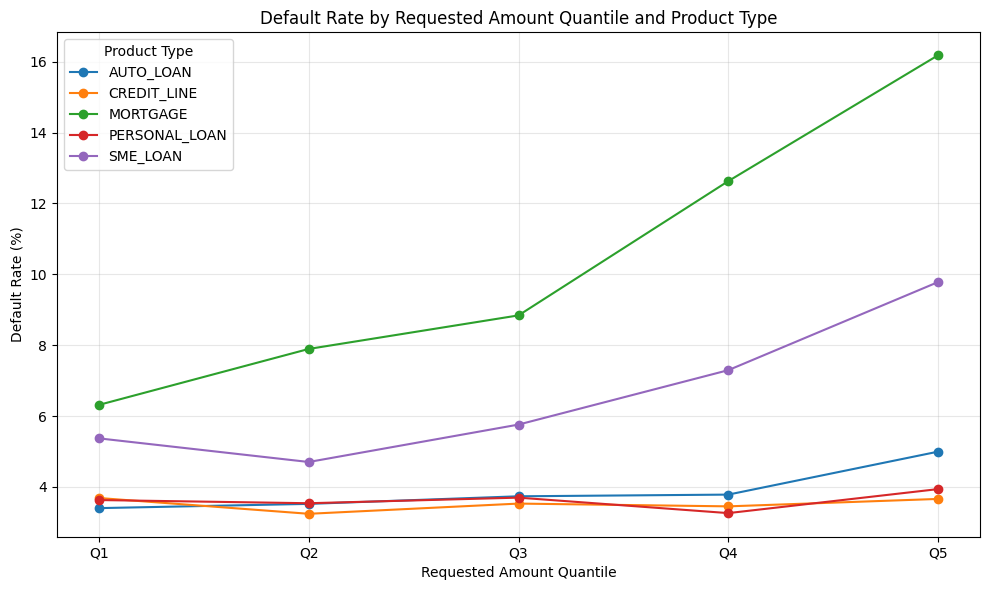

In [171]:
# 시각화용 데이터로 변환
plot_df = amount_default.reset_index()

plt.figure(figsize=(10, 6))

for product in plot_df["product_type"].unique():
    temp = plot_df[plot_df["product_type"] == product]

    plt.plot(
        temp["amount_group"].astype(str),
        temp["default_rate"],
        marker="o",
        label=product
    )

plt.xlabel("Requested Amount Quantile")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Requested Amount Quantile and Product Type")

plt.legend(title="Product Type")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/default_rate_by_product_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [157]:
model_df["amount_income_ratio"] = (
    model_df["requested_amount"] / model_df["annual_income"]
)

In [158]:
model_df["amount_income_ratio"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count   137,094.00
mean          0.53
std           1.18
min           0.00
50%           0.26
75%           0.54
90%           1.07
95%           1.63
99%           4.95
max          49.25
Name: amount_income_ratio, dtype: float64

In [142]:
model_df["amount_income_group"] = pd.qcut(
    model_df["amount_income_ratio"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
)

In [143]:
amount_income_default = (
    model_df
    .groupby(
        "amount_income_group",
        observed=True
    )["default_12m_label"]
    .agg(["count", "mean"])
)

amount_income_default["default_rate"] = (
    amount_income_default["mean"] * 100
)

amount_income_default

,count,mean,default_rate
amount_income_group,,,
Q1,27419,0.03,2.86
Q2,27419,0.03,3.48
Q3,27418,0.03,3.40
Q4,27419,0.04,3.63
Q5,27419,0.07,6.89


In [144]:
loan_purpose_default = (
    model_df
    .groupby("loan_purpose")["default_12m_label"]
    .agg(["count", "mean"])
)

loan_purpose_default["default_rate"] = (
    loan_purpose_default["mean"] * 100
)

loan_purpose_default.sort_values(
    "default_rate",
    ascending=False
)

,count,mean,default_rate
loan_purpose,,,
대환,17250,0.04,4.28
사업운영,17237,0.04,4.18
자동차구매,17223,0.04,4.13
생활자금,16867,0.04,4.13
교육,17212,0.04,4.01
투자,17102,0.04,3.96
주택구입,17076,0.04,3.94
의료,17127,0.04,3.78


In [161]:
numeric_cols = [
    "requested_amount",
    "employment_years",
    "debt_to_income",
    "bureau_score",
    "internal_css_score",
    "amount_income_ratio",
    "annual_income"
]

In [162]:
display(model_df[numeric_cols].corr(numeric_only=True).round(3)) # 상관관계 분석 함수

,requested_amount,employment_years,debt_to_income,bureau_score,internal_css_score,amount_income_ratio,annual_income
requested_amount,1.00,0.02,0.70,0.08,-0.26,0.81,0.09
employment_years,0.02,1.00,0.03,-0.02,0.04,0.03,-0.01
debt_to_income,0.70,0.03,1.00,-0.08,-0.34,0.71,-0.23
bureau_score,0.08,-0.02,-0.08,1.00,0.20,-0.04,0.42
internal_css_score,-0.26,0.04,-0.34,0.20,1.00,-0.29,0.13
amount_income_ratio,0.81,0.03,0.71,-0.04,-0.29,1.00,-0.15
annual_income,0.09,-0.01,-0.23,0.42,0.13,-0.15,1.00


In [8]:
application_date_summary = (
    model_df
    .assign(
        application_month=model_df["application_at"].dt.to_period("M")
    )
    .groupby("application_month")
    .size()
    .reset_index(name="application_count")
)

application_date_summary

,application_month,application_count
0,2021-08,2956
1,2021-09,2853
2,2021-10,2939
3,2021-11,2872
4,2021-12,2883
5,2022-01,2975
6,2022-02,2543
7,2022-03,2906
8,2022-04,2871
9,2022-05,2919
